# Diffusion SBI toy SED validation

This notebook is a fast diagnostic rung for the experimental conditional diffusion sampler.  The simulator is intentionally toy-level, but it has the same data shape as a small SED problem: eight broad-band magnitudes plus four physical parameters.

The goal is not to validate FSPS, CIGALE, DSPS, or Cue.  It checks whether the diffusion model can condition on arbitrary known entries, preserve those known entries exactly, and produce plausible inverse/forward/missing-band conditionals against a brute-force Monte Carlo reference posterior.

## Scientific data flow

1. Draw parameters from a simple prior: redshift, stellar mass, dust, and metallicity.
2. Convert parameters to toy observed magnitudes in `ugrizYJH` with explicit Gaussian magnitude noise.
3. Train a joint diffusion model on `[magnitudes, parameters]` with random conditioning masks.
4. Compare `theta | magnitudes` and mixed missing-band conditionals to a brute-force prior-bank reference.
5. Check the forward conditional `magnitudes | theta` against the known toy noise model.

The key scientific operations to audit are in `examples/experimental_diffusion_toy_sed_validation.py`: `toy_noiseless_magnitudes`, `reference_inverse_samples`, `reference_mixed_samples`, and `run_validation`.

In [1]:
from pathlib import Path
import sys

candidate_roots = [Path.cwd(), *Path.cwd().parents]
for root in candidate_roots:
    if (root / "examples" / "experimental_diffusion_toy_sed_validation.py").exists():
        PROJECT_ROOT = root
        break
else:
    raise RuntimeError("Could not locate the CompoSED project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/gregoire/Documents/Sedfitting/CompoSED')

In [2]:
from examples.experimental_diffusion_toy_sed_validation import run_validation

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "diffusion_toy_sed_validation_notebook"
metrics = run_validation(output_dir=OUTPUT_DIR)
metrics

{'device': 'mps',
 'final_train_loss': 0.44851261004805565,
 'n_epochs': 90,
 'inverse_theta_given_all_mags': {'unknown_features': ['redshift',
   'log10_mass',
   'dust2',
   'logzsol'],
  'reference_ess_median': 113.01721296899234,
  'reference_ess_min': 23.592879195462718,
  'normalized_mean_abs_error': {'redshift': 1.4412275763274327,
   'log10_mass': 0.6929636428715594,
   'dust2': 1.3507205767231627,
   'logzsol': 0.2286360046283195},
  'std_relative_error': {'redshift': 0.8604044092973113,
   'log10_mass': 0.3555594759750388,
   'dust2': 0.49863331765342184,
   'logzsol': 0.07737710096851948},
  'truth_rmse': {'redshift': 0.46800142013201856,
   'log10_mass': 0.28836768239471877,
   'dust2': 0.3762608897670794,
   'logzsol': 0.533775821579024},
  'coverage_68': {'redshift': 0.5,
   'log10_mass': 0.5,
   'dust2': 0.3125,
   'logzsol': 0.25},
  'seconds': 0.1363405839947518,
  'known_max_abs_error': 0.0},
 'forward_mags_given_theta': {'mean_rmse_mag': 0.32237034099437206,
  'std_r

## Diagnostic plots

These plots are deliberately plain.  We want to see whether the generated posterior samples are causally connected to the toy simulator, not whether the plot styling is flattering.

training_loss.png


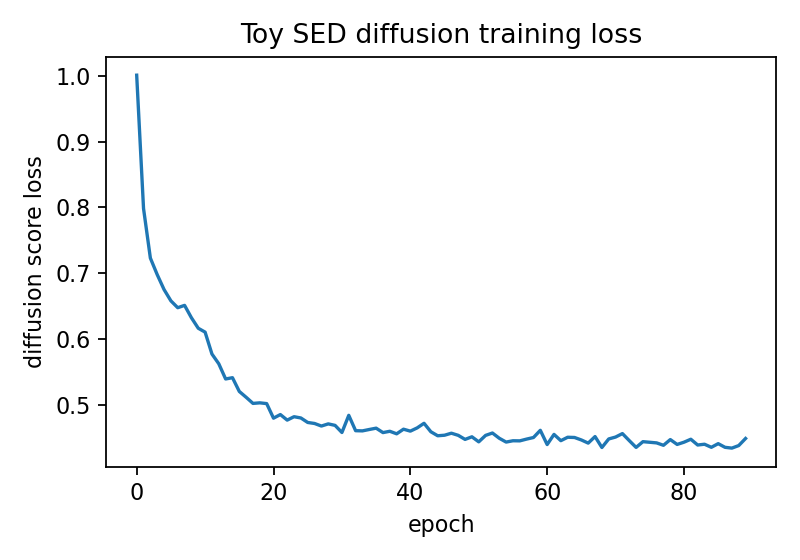

inverse_theta_given_mags_summary.png


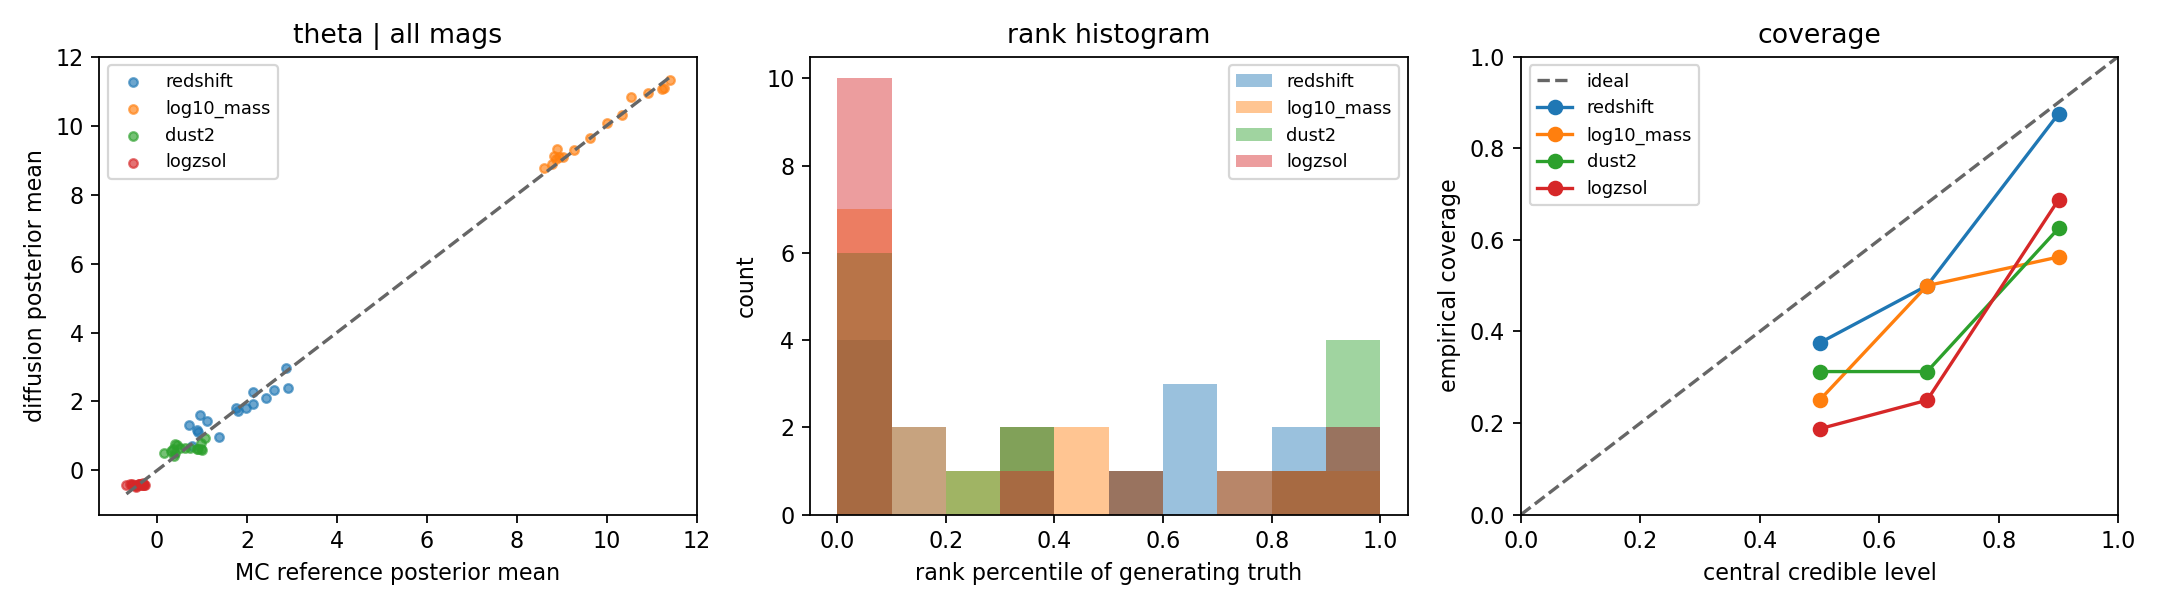

forward_mags_given_theta_summary.png


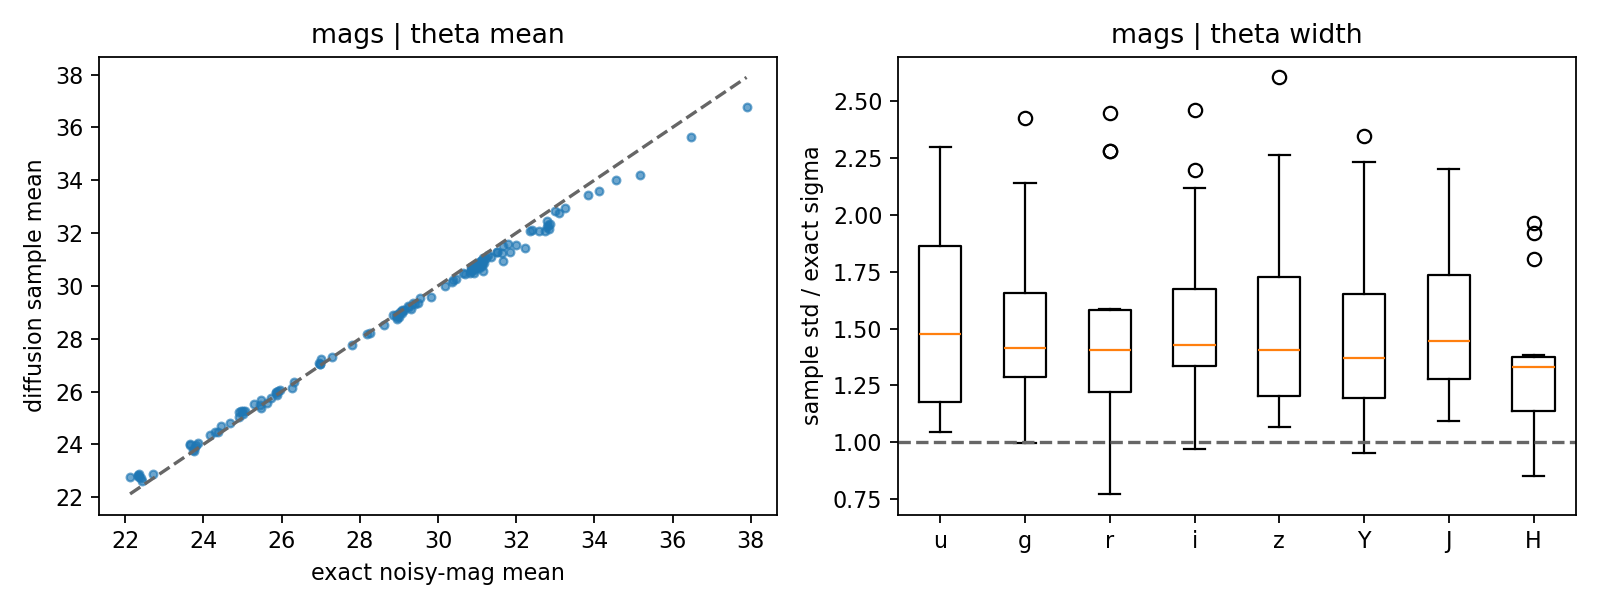

mixed_missing_band_summary.png


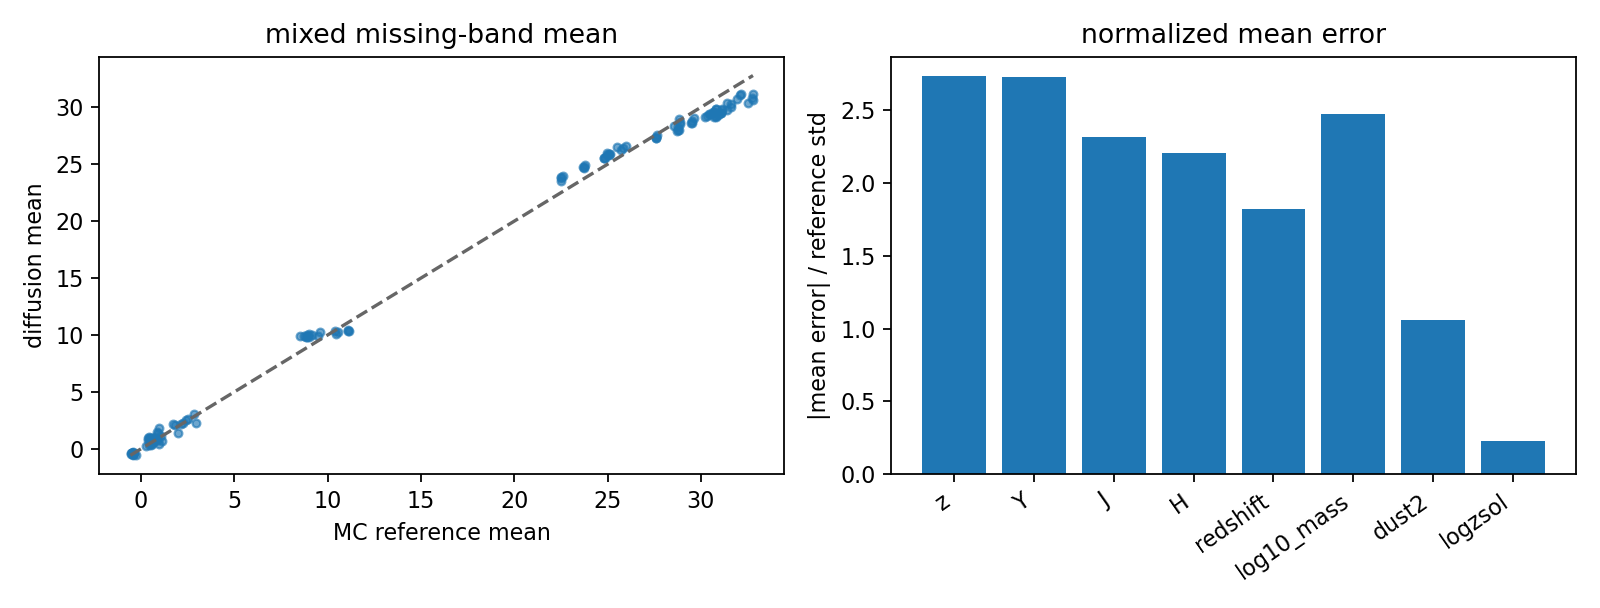

toy_sed_posterior_predictive_example.png


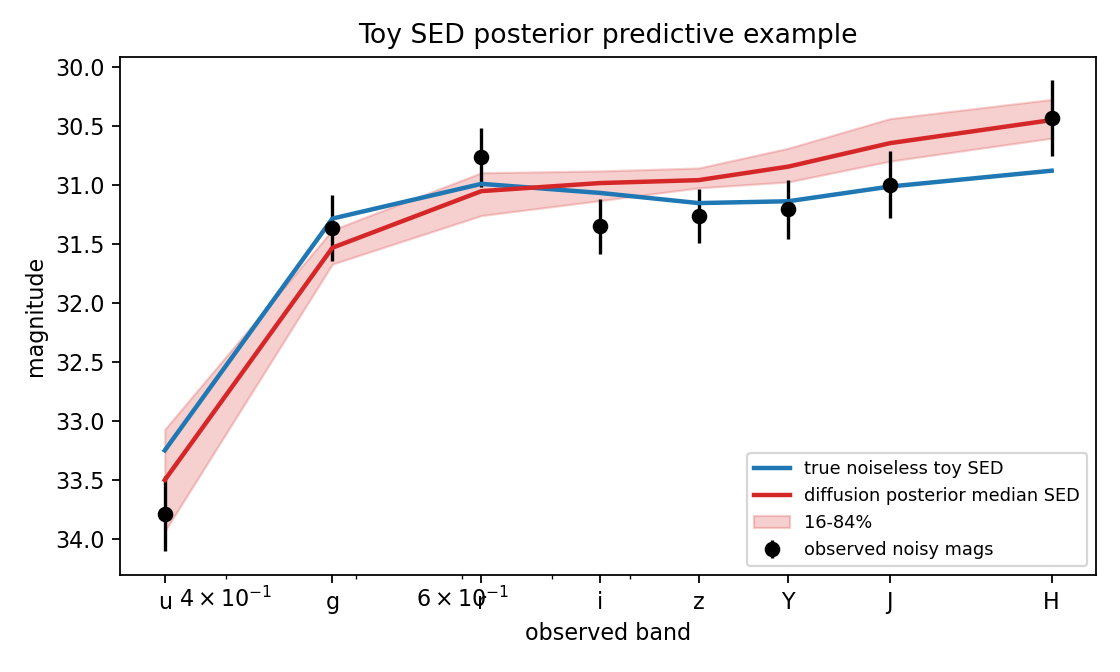

In [3]:
from IPython.display import Image, display

for filename in [
    "training_loss.png",
    "inverse_theta_given_mags_summary.png",
    "forward_mags_given_theta_summary.png",
    "mixed_missing_band_summary.png",
    "toy_sed_posterior_predictive_example.png",
]:
    print(filename)
    display(Image(filename=str(OUTPUT_DIR / filename)))